# 2 · Hands-on: Simulating Photon Statistics

**Interactive session · Monday July 27, 14:00–15:00 · work in pairs**

You will now build every state from this morning's lecture yourself, "measure" it with a simulated photon counter, and then destroy its quantumness with optical loss.

### Learning objectives

1. build coherent / thermal / Fock states in **QuTiP** and extract $P(n)$, $\langle n\rangle$, $(\Delta n)^2$,
2. Monte-Carlo-sample detector clicks from a photon number distribution and estimate statistics *from data*,
3. show numerically what **loss** does to sub-Poissonian light.

### How the exercises work

Cells marked **`# YOUR CODE HERE`** are yours. Each exercise has a ✅ *self-check* cell right after it — run it to test your solution. Sample solutions are at the very bottom of the notebook: **try first, peek later.**

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(2026)
print("qutip", qutip.__version__, "- ready")

qutip 5.3.0 - ready


## Warm-up (worked example): states and $P(n)$ in QuTiP

QuTiP represents a field mode in a **truncated** Fock space of dimension `N` — always check that your states fit well below the cutoff (rule of thumb: `N > nbar + 5*sqrt(nbar)`).

Three constructors do everything we need today:

```python
qutip.fock(N, n)             # Fock state |n>            (a ket)
qutip.coherent(N, alpha)     # coherent state |alpha>    (a ket)
qutip.thermal_dm(N, nbar)    # thermal state              (a density matrix!)
```

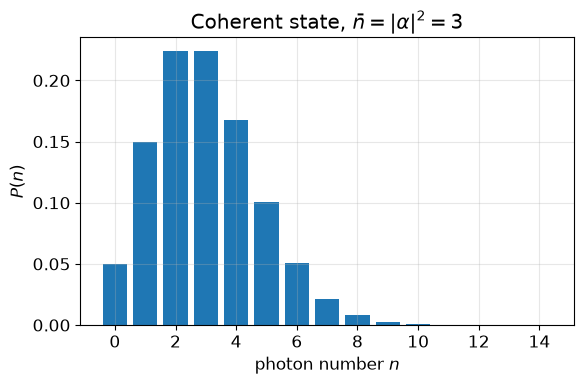

check: <n> = 3.0  (expected 3.0)


In [2]:
N = 100  # Fock-space cutoff. Thermal tails are long: too small a cutoff
         # biases the variance downward (try N = 30 and watch Q shrink!)

def photon_number_distribution(state) -> np.ndarray:
    """P(n) for a single-mode state (ket or density matrix).

    The photon number distribution is the diagonal of the density
    matrix in the Fock basis: P(n) = <n| rho |n>.
    """
    rho = qutip.ket2dm(state) if state.isket else state
    return np.real(rho.diag())

# Example: a coherent state with nbar = 3  ->  alpha = sqrt(3)
alpha = np.sqrt(3.0)
psi = qutip.coherent(N, alpha)
P = photon_number_distribution(psi)

plt.bar(np.arange(15), P[:15], color="tab:blue")
plt.xlabel("photon number $n$")
plt.ylabel("$P(n)$")
plt.title(r"Coherent state, $\bar{n} = |\alpha|^2 = 3$")
plt.tight_layout()
plt.show()

print("check: <n> =", np.sum(np.arange(N) * P).round(4), " (expected 3.0)")

## Exercise 1 · The fingerprint figure

Recreate the central figure of Lecture 1: $P(n)$ for a **Fock**, a **coherent**, and a **thermal** state, *all with* $\bar n = 5$, in one plot (bars or steps, your choice — label everything).

*New physics to notice while you plot:* at $\bar n = 5$, what is the single most likely photon number for the thermal state?

In [3]:
# YOUR CODE HERE - Exercise 1
nbar = 5

# build the three states:
# psi_fock = ...
# psi_coh = ...
# rho_th = ...

# plot their photon number distributions in one figure


In [4]:
# ✅ self-check for Exercise 1 (run after your solution)
try:
    for name, st in [("Fock", psi_fock), ("coherent", psi_coh),
                     ("thermal", rho_th)]:
        P = photon_number_distribution(st)
        mean = np.sum(np.arange(len(P)) * P)
        assert abs(mean - 5) < 0.05, f"{name}: <n> = {mean:.2f}, expected 5"
    assert photon_number_distribution(rho_th)[0] > \
           photon_number_distribution(rho_th)[1], \
           "thermal P(0) should exceed P(1) - always!"
    print("Exercise 1 looks correct: all three states have <n> = 5,")
    print("and yes - for thermal light n=0 is STILL the most likely outcome.")
except NameError:
    print("(not solved yet - define psi_fock, psi_coh, rho_th above)")

(not solved yet - define psi_fock, psi_coh, rho_th above)


## Exercise 2 · A `mandel_Q` function

Write the function below and test it. Reminder from the lecture:

$$Q = \frac{(\Delta n)^2 - \bar n}{\bar n},\qquad (\Delta n)^2 = \langle \hat n^2\rangle - \langle \hat n\rangle^2 .$$

Useful QuTiP bits: `qutip.num(N)` is $\hat n$; `qutip.expect(op, state)` works for kets *and* density matrices; operators square with `**2`.

Expected values: coherent $\to 0$, thermal $\to \bar n$, Fock $\to -1$.

In [5]:
def mandel_Q(state) -> float:
    """Mandel Q parameter: (variance - mean)/mean of the photon number.

    Q = 0 Poissonian | Q < 0 sub-Poissonian (non-classical) | Q > 0 super-P.
    """
    # YOUR CODE HERE - Exercise 2
    raise NotImplementedError

In [6]:
# ✅ self-check for Exercise 2
try:
    q_coh = mandel_Q(qutip.coherent(N, 2.0))
    q_th = mandel_Q(qutip.thermal_dm(N, 4.0))
    q_fock = mandel_Q(qutip.fock(N, 4))
    assert abs(q_coh) < 1e-6, f"coherent: Q = {q_coh}, expected 0"
    assert abs(q_th - 4.0) < 1e-3, f"thermal nbar=4: Q = {q_th}, expected 4"
    assert abs(q_fock + 1.0) < 1e-9, f"Fock: Q = {q_fock}, expected -1"
    print(f"Exercise 2 correct:  Q_coh = {q_coh:+.4f}, "
          f"Q_th = {q_th:+.4f}, Q_fock = {q_fock:+.4f}")
except NotImplementedError:
    print("(not solved yet - implement mandel_Q above)")

(not solved yet - implement mandel_Q above)


## Exercise 3 · Statistics of estimating statistics

Real experiments don't hand you $P(n)$ — they hand you a **finite number of measurements**. Simulate a photon-counting experiment:

1. draw `n_shots = 10_000` photon-number samples from the $P(n)$ of each of your three states (`rng.choice(np.arange(N), size=n_shots, p=P)` does this),
2. estimate $\bar n$, $(\Delta n)^2$ and $Q$ **from the samples** (`np.mean`, `np.var`),
3. compare with the exact values from Exercise 2.

*Question to discuss with your neighbor:* repeat with `n_shots = 100`. How reliably can you still certify $Q<0$ for the Fock state? What does that mean for a real experiment with limited measurement time?

In [7]:
# YOUR CODE HERE - Exercise 3
n_shots = 10_000

# for each state: samples = rng.choice(np.arange(N), size=n_shots, p=P)
#                 Q_est   = (np.var(samples) - np.mean(samples)) / np.mean(samples)


## Stretch exercise · Loss eats quantumness

Optical loss (transmission $\eta$) acts on photons like a biased coin: each photon survives independently with probability $\eta$. On the level of $P(n)$ this is a **binomial thinning**:

$$P_\eta(m) \;=\; \sum_{n\ge m} P(n)\,\binom{n}{m}\,\eta^m (1-\eta)^{n-m}.$$

(The same result comes from a beamsplitter model where the lost photons exit the unused port — Wednesday we build exactly that in Perceval.)

**Task:** starting from the Fock state $|4\rangle$, compute and plot $Q$ after loss as a function of $\eta \in [0, 1]$ (use the binomial-thinning formula on $P(n)$, then your Q from moments of the thinned distribution — no QuTiP needed here).

You should find $Q(\eta) = -\eta$: the state stays sub-Poissonian for *any* $\eta > 0$…but barely. This is the daily life of single-photon experiments: **efficiency is everything.**

In [8]:
# YOUR CODE HERE - Stretch exercise
from scipy.stats import binom

eta_axis = np.linspace(0, 1, 21)

# P4 = photon_number_distribution(qutip.fock(N, 4))
# for each eta: thin P4, compute mean & var of the thinned distribution, get Q
# plot Q vs eta; overlay the prediction Q = -eta


---
## If you finish early

* Prove analytically that binomial thinning of a Poisson distribution is again Poisson (this is why attenuated lasers never become quantum).
* Compute $Q$ of the state $\rho = p\,|1\rangle\langle 1| + (1-p)\,|0\rangle\langle 0|$ (question 4 from the lecture) and check numerically.

## Handing in (optional today, required Tuesday)

```bash
mkdir -p submissions/<your-github-username>
cp lectures/02_HandsOn_SimulatingPhotonStatistics.ipynb submissions/<your-github-username>/
git add submissions/ && git commit -m "Lecture 2 exercises" && git push
```

---
---

# Sample solutions

**No peeking during the session** — these are for checking afterwards (and for anyone who got stuck at home).

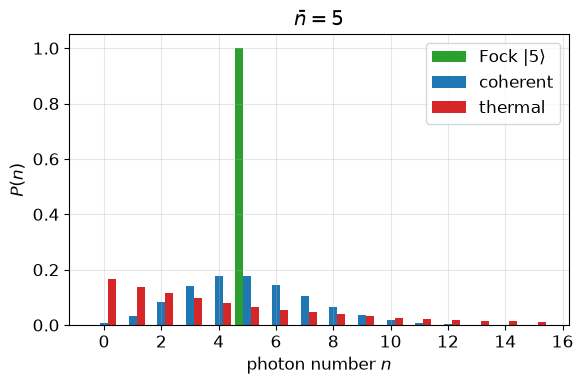

In [9]:
# Solution - Exercise 1
nbar = 5
psi_fock = qutip.fock(N, nbar)
psi_coh = qutip.coherent(N, np.sqrt(nbar))
rho_th = qutip.thermal_dm(N, nbar)

n_axis = np.arange(16)
width = 0.28
fig, ax = plt.subplots()
for i, (label, st, c) in enumerate([("Fock $|5\\rangle$", psi_fock, "tab:green"),
                                    ("coherent", psi_coh, "tab:blue"),
                                    ("thermal", rho_th, "tab:red")]):
    ax.bar(n_axis + (i - 1) * width,
           photon_number_distribution(st)[:len(n_axis)], width,
           label=label, color=c)
ax.set_xlabel("photon number $n$"); ax.set_ylabel("$P(n)$")
ax.set_title(r"$\bar{n} = 5$"); ax.legend(); plt.tight_layout(); plt.show()

In [10]:
# Solution - Exercise 2
def mandel_Q(state) -> float:
    """Mandel Q parameter: (variance - mean)/mean of the photon number."""
    n_op = qutip.num(state.shape[0])
    mean = qutip.expect(n_op, state)
    var = qutip.expect(n_op**2, state) - mean**2
    return (var - mean) / mean

for label, st in [("coherent", psi_coh), ("thermal", rho_th),
                  ("Fock", psi_fock)]:
    print(f"{label:9s} Q = {mandel_Q(st):+.4f}")

coherent  Q = -0.0000
thermal   Q = +5.0000
Fock      Q = -1.0000


In [11]:
# Solution - Exercise 3
n_shots = 10_000
print(f"{'state':<10}{'Q exact':>10}{'Q estimated':>14}")
for label, st in [("coherent", psi_coh), ("thermal", rho_th),
                  ("Fock", psi_fock)]:
    P = photon_number_distribution(st)
    P = P / P.sum()                       # numerical safety renormalization
    samples = rng.choice(np.arange(N), size=n_shots, p=P)
    q_est = (np.var(samples) - np.mean(samples)) / np.mean(samples)
    print(f"{label:<10}{mandel_Q(st):>+10.3f}{q_est:>+14.3f}")
# With n_shots = 100 the Fock-state Q estimate scatters by ~0.1-0.2:
# certifying nonclassicality needs statistics, not just one lucky run.

state        Q exact   Q estimated
coherent      -0.000        -0.005
thermal       +5.000        +4.907
Fock          -1.000        -1.000


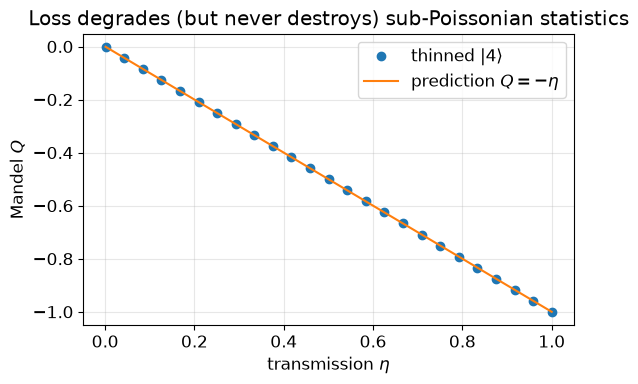

In [12]:
# Solution - Stretch exercise
from scipy.stats import binom

def thin(P: np.ndarray, eta: float) -> np.ndarray:
    """Binomial thinning of a photon number distribution with transmission eta."""
    N_dim = len(P)
    P_out = np.zeros(N_dim)
    for n in range(N_dim):
        if P[n] > 0:
            m = np.arange(n + 1)
            P_out[:n + 1] += P[n] * binom.pmf(m, n, eta)
    return P_out

P4 = photon_number_distribution(qutip.fock(N, 4))
eta_axis = np.linspace(0.001, 1, 25)
Q_vals = []
for eta in eta_axis:
    Pt = thin(P4, eta)
    n = np.arange(N)
    mean = np.sum(n * Pt)
    var = np.sum(n**2 * Pt) - mean**2
    Q_vals.append((var - mean) / mean)

plt.plot(eta_axis, Q_vals, "o", label="thinned $|4\\rangle$")
plt.plot(eta_axis, -eta_axis, "-", label=r"prediction $Q = -\eta$")
plt.xlabel(r"transmission $\eta$"); plt.ylabel("Mandel $Q$")
plt.title("Loss degrades (but never destroys) sub-Poissonian statistics")
plt.legend(); plt.tight_layout(); plt.show()